<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/03.variational-learning-and-kernels/02.quantum-kernels/day23_04_02_example_kernel_matrix_heatmap_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day23 Quantum Kernel Matrix Heatmap 실습

- Source: Google Drive `Day23/4-2.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


STEP 1. Kernel Matrix 준비
Kernel Matrix
[[1.   0.89 0.32 0.28 0.19]
 [0.89 1.   0.35 0.3  0.21]
 [0.32 0.35 1.   0.87 0.82]
 [0.28 0.3  0.87 1.   0.84]
 [0.19 0.21 0.82 0.84 1.  ]]

STEP 2. Kernel Matrix 확인
Matrix Shape : (5, 5)

Minimum Similarity : 0.19
Maximum Similarity : 1.0

Diagonal Values
[1. 1. 1. 1. 1.]

STEP 3. 기본 Heatmap 생성


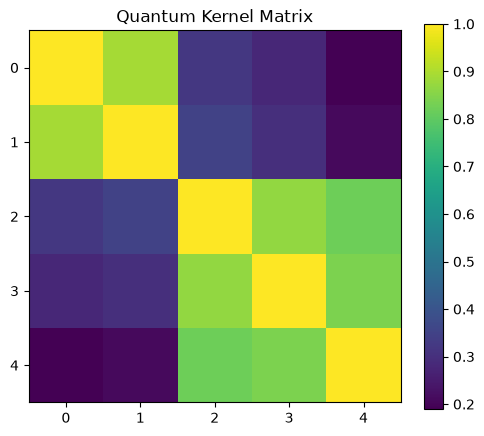


STEP 4. Color Map 비교


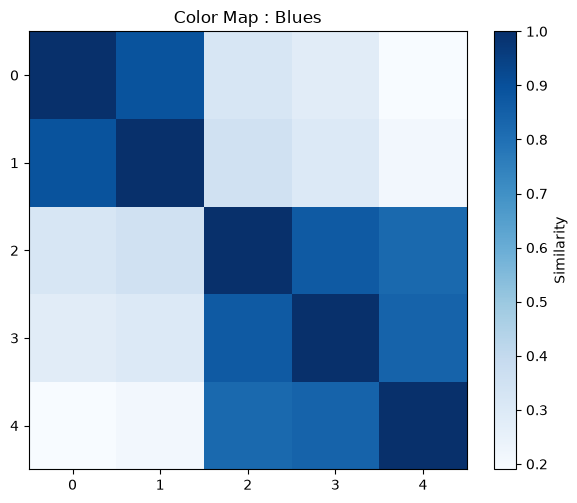

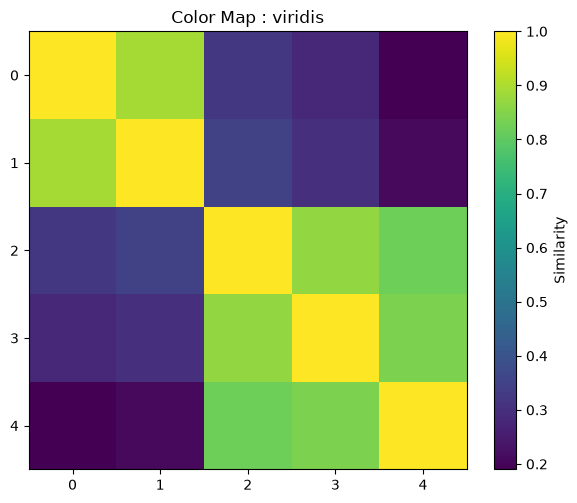

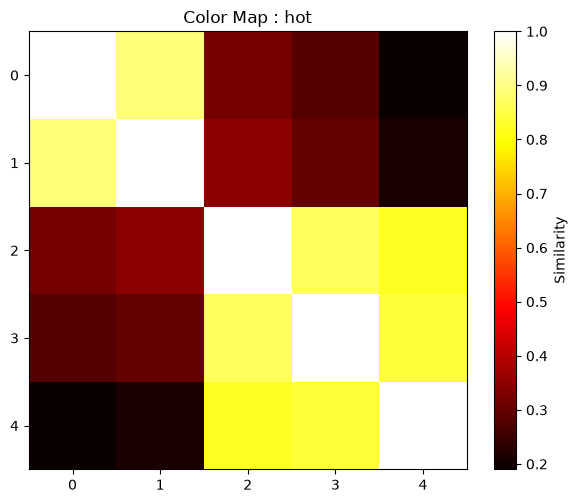


STEP 5. Sample Label 추가


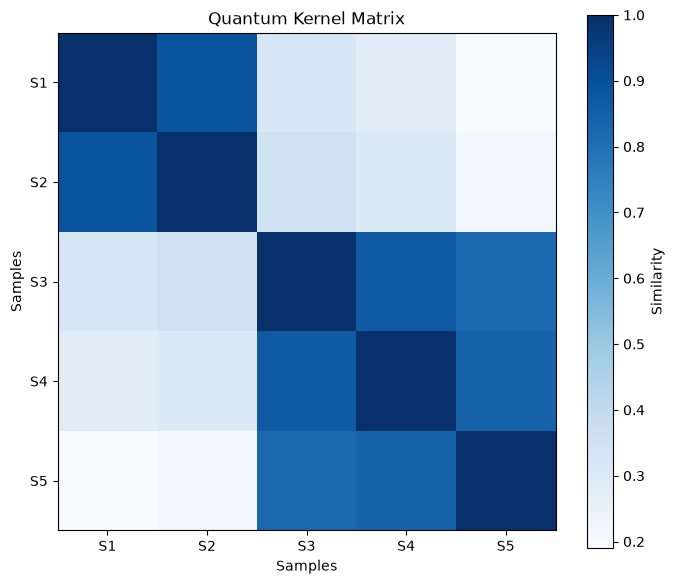


STEP 6. Class Label 표시


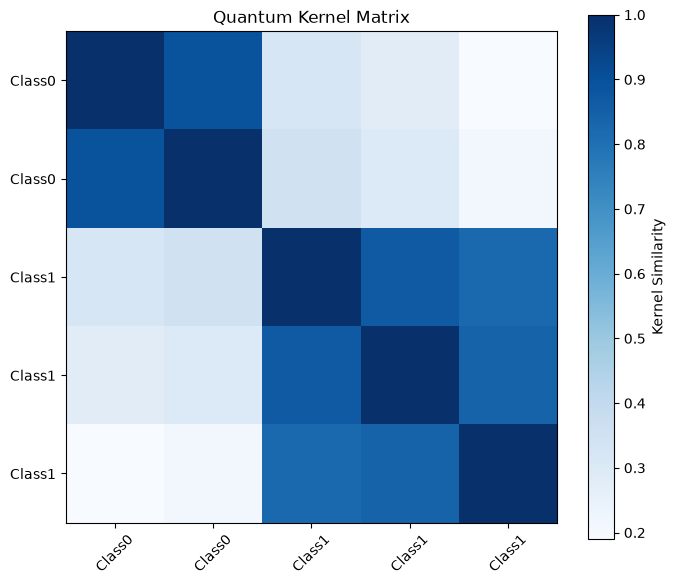


STEP 7. Heatmap 함수


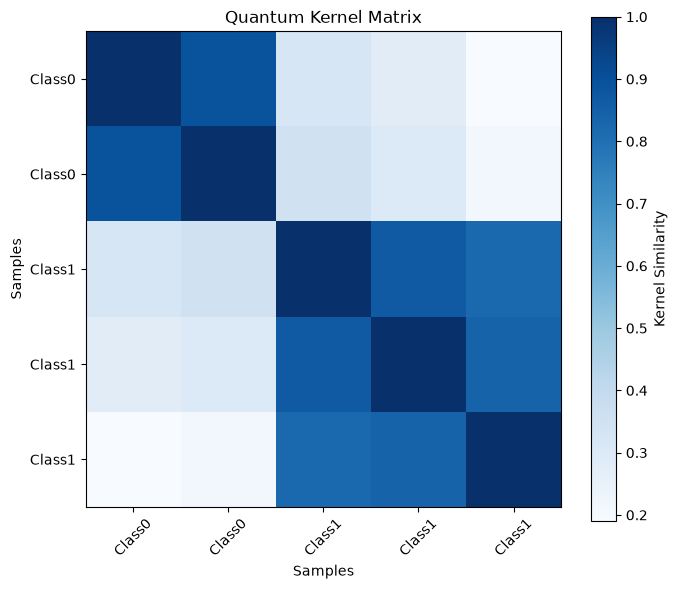


STEP 8. Heatmap 분석
1. 대각선 확인
[1. 1. 1. 1. 1.]
→ 자기 자신과의 Similarity가 1입니다.

2. Matrix 대칭성
True

3. 평균 Similarity
0.6056

4. 최대 Similarity
1.0

5. 최소 Similarity
0.19

STEP 9. Heatmap 해석

Heatmap 해석 방법

① 대각선
   → 자기 자신과의 Similarity

② 왼쪽 위 Block
   → Class 0 내부 Similarity

③ 오른쪽 아래 Block
   → Class 1 내부 Similarity

④ 가운데 영역
   → 서로 다른 Class Similarity

⑤ Block이 선명할수록
   → Feature Map이 클래스를 잘 구분


STEP 10. 분석 결과

Kernel Matrix 크기

(5, 5)

최소 Similarity

0.190

최대 Similarity

1.000

평균 Similarity

0.606

대칭 Matrix

True

Diagonal

[1. 1. 1. 1. 1.]


결과 해석

- 대각선은 모두 1에 가까우므로
  자기 자신과의 Similarity가 정상적으로 계산되었다.

- Matrix는 대칭이다.

- 같은 클래스는 높은 Similarity를 가진다.

- 다른 클래스는 낮은 Similarity를 가진다.

- Heatmap에서 Block 구조가 나타난다면
  현재 Quantum Feature Map이
  데이터를 잘 표현하고 있다고 해석할 수 있다.

Lab 완료


In [1]:
# ============================================================
# Quantum Kernel Matrix Heatmap 생성 및 데이터 구조 분석
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# STEP 1. Kernel Matrix 준비
# ============================================================

print("=" * 80)
print("STEP 1. Kernel Matrix 준비")
print("=" * 80)

kernel_matrix = np.array([
    [1.00, 0.89, 0.32, 0.28, 0.19],
    [0.89, 1.00, 0.35, 0.30, 0.21],
    [0.32, 0.35, 1.00, 0.87, 0.82],
    [0.28, 0.30, 0.87, 1.00, 0.84],
    [0.19, 0.21, 0.82, 0.84, 1.00]
])

labels = [
    "Class0",
    "Class0",
    "Class1",
    "Class1",
    "Class1"
]

print("Kernel Matrix")
print(kernel_matrix)

# ============================================================
# STEP 2. Kernel Matrix 확인
# ============================================================

print("\n" + "=" * 80)
print("STEP 2. Kernel Matrix 확인")
print("=" * 80)

print("Matrix Shape :", kernel_matrix.shape)

print("\nMinimum Similarity :", np.min(kernel_matrix))
print("Maximum Similarity :", np.max(kernel_matrix))

print("\nDiagonal Values")
print(np.diag(kernel_matrix))

# ============================================================
# STEP 3. 가장 기본적인 Heatmap
# ============================================================

print("\n" + "=" * 80)
print("STEP 3. 기본 Heatmap 생성")
print("=" * 80)

plt.figure(figsize=(6,5))

plt.imshow(kernel_matrix)

plt.colorbar()

plt.title("Quantum Kernel Matrix")

plt.show()

# ============================================================
# STEP 4. Color Map 비교
# ============================================================

print("\n" + "=" * 80)
print("STEP 4. Color Map 비교")
print("=" * 80)

color_maps = [
    "Blues",
    "viridis",
    "hot"
]

for cmap in color_maps:

    plt.figure(figsize=(6,5))

    plt.imshow(
        kernel_matrix,
        cmap=cmap
    )

    plt.colorbar(label="Similarity")

    plt.title(f"Color Map : {cmap}")

    plt.tight_layout()

    plt.show()

# ============================================================
# STEP 5. 축(Label) 추가
# ============================================================

print("\n" + "=" * 80)
print("STEP 5. Sample Label 추가")
print("=" * 80)

sample_names = [
    "S1",
    "S2",
    "S3",
    "S4",
    "S5"
]

plt.figure(figsize=(7,6))

plt.imshow(
    kernel_matrix,
    cmap="Blues"
)

plt.xticks(
    range(len(sample_names)),
    sample_names
)

plt.yticks(
    range(len(sample_names)),
    sample_names
)

plt.colorbar(label="Similarity")

plt.title("Quantum Kernel Matrix")

plt.xlabel("Samples")

plt.ylabel("Samples")

plt.tight_layout()

plt.show()

# ============================================================
# STEP 6. Label(Class) 표시
# ============================================================

print("\n" + "=" * 80)
print("STEP 6. Class Label 표시")
print("=" * 80)

plt.figure(figsize=(7,6))

plt.imshow(
    kernel_matrix,
    cmap="Blues"
)

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.colorbar(label="Kernel Similarity")

plt.title("Quantum Kernel Matrix")

plt.tight_layout()

plt.show()

# ============================================================
# STEP 7. Heatmap 생성 함수
# ============================================================

print("\n" + "=" * 80)
print("STEP 7. Heatmap 함수")
print("=" * 80)

def plot_kernel_heatmap(
    kernel_matrix,
    labels=None,
    title="Quantum Kernel Matrix",
    cmap="Blues"
):
    """
    Quantum Kernel Matrix Heatmap 출력
    """

    plt.figure(figsize=(7,6))

    plt.imshow(
        kernel_matrix,
        cmap=cmap,
        interpolation="nearest"
    )

    plt.colorbar(
        label="Kernel Similarity"
    )

    if labels is not None:

        plt.xticks(
            range(len(labels)),
            labels,
            rotation=45
        )

        plt.yticks(
            range(len(labels)),
            labels
        )

    plt.title(title)

    plt.xlabel("Samples")

    plt.ylabel("Samples")

    plt.tight_layout()

    plt.show()

plot_kernel_heatmap(
    kernel_matrix,
    labels,
    "Quantum Kernel Matrix"
)

# ============================================================
# STEP 8. Heatmap 분석
# ============================================================

print("\n" + "=" * 80)
print("STEP 8. Heatmap 분석")
print("=" * 80)

print("1. 대각선 확인")

diagonal = np.diag(kernel_matrix)

print(diagonal)

if np.allclose(diagonal, 1):
    print("→ 자기 자신과의 Similarity가 1입니다.")

print()

print("2. Matrix 대칭성")

print(
    np.allclose(
        kernel_matrix,
        kernel_matrix.T
    )
)

print()

print("3. 평균 Similarity")

print(np.mean(kernel_matrix))

print()

print("4. 최대 Similarity")

print(np.max(kernel_matrix))

print()

print("5. 최소 Similarity")

print(np.min(kernel_matrix))

# ============================================================
# STEP 9. Heatmap 해석
# ============================================================

print("\n" + "=" * 80)
print("STEP 9. Heatmap 해석")
print("=" * 80)

print("""
Heatmap 해석 방법

① 대각선
   → 자기 자신과의 Similarity

② 왼쪽 위 Block
   → Class 0 내부 Similarity

③ 오른쪽 아래 Block
   → Class 1 내부 Similarity

④ 가운데 영역
   → 서로 다른 Class Similarity

⑤ Block이 선명할수록
   → Feature Map이 클래스를 잘 구분
""")

# ============================================================
# STEP 10. 분석 결과 출력
# ============================================================

print("\n" + "=" * 80)
print("STEP 10. 분석 결과")
print("=" * 80)

print(f"""
Kernel Matrix 크기

{kernel_matrix.shape}

최소 Similarity

{kernel_matrix.min():.3f}

최대 Similarity

{kernel_matrix.max():.3f}

평균 Similarity

{kernel_matrix.mean():.3f}

대칭 Matrix

{np.allclose(kernel_matrix, kernel_matrix.T)}

Diagonal

{np.diag(kernel_matrix)}
""")

print("""
결과 해석

- 대각선은 모두 1에 가까우므로
  자기 자신과의 Similarity가 정상적으로 계산되었다.

- Matrix는 대칭이다.

- 같은 클래스는 높은 Similarity를 가진다.

- 다른 클래스는 낮은 Similarity를 가진다.

- Heatmap에서 Block 구조가 나타난다면
  현재 Quantum Feature Map이
  데이터를 잘 표현하고 있다고 해석할 수 있다.
""")

print("=" * 80)
print("Lab 완료")
print("=" * 80)